In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.model_selection import train_test_split, cross_val_score, ShuffleSplit, cross_val_predict
from sklearn.linear_model import LinearRegression
from sklearn import metrics

chemin = 'BD_2016_2020_TableauDynamique.xlsx'
df = pd.read_excel(chemin, sheet_name="Extraction juin 2016 juin 2020")

# Renommer les colonnes : supprimer espaces, flèches, caractères spéciaux
import re

def clean_column_name(col):
    """Nettoie le nom de colonne : supprime espaces, flèches, caractères spéciaux"""
    # Remplacer les flèches par underscore
    col = col.replace('->', '_')
    col = col.replace('→', '_')
    # Remplacer les espaces par underscore
    col = col.replace(' ', '_')
    # Supprimer les caractères spéciaux
    col = re.sub(r'[^a-zA-Z0-9_]', '', col)
    # Supprimer les underscores multiples
    col = re.sub(r'_+', '_', col)
    # Transformer en minuscules
    col = col.lower()
    return col

df.columns = [clean_column_name(col) for col in df.columns]
print("Colonnes renommées :")
print(df.columns.tolist())

# =========================================
# CHUNK 2 — Parsing datetime robuste (mix)
# =========================================
def parse_dt_mixed(s: pd.Series) -> pd.Series:
    """
    Parse dates potentiellement mixtes:
    - strings datetime (ex: '2020-01-01 12:34')
    - serial Excel (float/int) jours depuis 1899-12-30
    """
    s0 = s.copy()
    dt = pd.to_datetime(s0, errors="coerce")

    mask = dt.isna() & s0.notna()
    if mask.any():
        num = pd.to_numeric(s0[mask], errors="coerce")
        dt2 = pd.to_datetime(num, unit="D", origin=EXCEL_ORIGIN, errors="coerce")
        dt.loc[mask] = dt2

    return dt

# Colonnes datetime utiles (selon ta liste)
df["arrive_dt"] = parse_dt_mixed(df["_informations_du_passage_date_et_heure_darrive"])
df["pec_dt"]    = parse_dt_mixed(df["_informations_du_passage_date_dbut_prise_en_charge_mdicale"])
df["box_dt"]    = parse_dt_mixed(df["_localisation_date_dentre_en_box"])
df["sortie_dt"] = parse_dt_mixed(df["_informations_du_passage_date_et_heure_de_sortie"])

# Bio (optionnel mais utile)
df["bio_presc_dt"] = parse_dt_mixed(df["_examens_complmentaires_date_et_heure_de_premire_prescription_de_biologie"])
df["bio_samp_dt"]  = parse_dt_mixed(df["_examens_complmentaires_date_et_heure_de_premier_prlvement_de_biologie"])

print(df[["arrive_dt","pec_dt","box_dt","sortie_dt"]].isna().mean().round(3))

Colonnes renommées :
['num_dordre', 'date', 'heure', '_informations_du_passage_date_et_heure_darrive', '_informations_du_passage_moyen_darrive', '_iao_motif_dentre', '_iao_motif_de_venue', '_patient_age_en_anne', '_antcdent_antcdents_mdicaux', '_antcdent_antcdents_chirurgicaux', '_constante_surveillances_paspad_adultes_premire_valeur', '_constante_surveillances_fc_adultes_premire_valeur', '_constante_surveillances_temprature_adultes_premire_valeur', '_constante_surveillances_sao2_adultes_premire_valeur', '_constante_surveillances_frquence_respiratoire_premire_valeur', '_diagnostic_code_ccmu', '_localisation_salles', '_localisation_date_dentre_en_box', '_anamnse_texte', '_iao_observation', '_examens_complmentaires_a_des_examens_de_biologie', '_examens_complmentaires_a_des_examens_de_radiologie', '_examens_complmentaires_a_des_examens_dchographie', '_examens_complmentaires_a_des_examens_de_scanner', '_examens_complmentaires_a_des_examens_dirm', '_examens_complmentaires_a_des_avis_de_spci

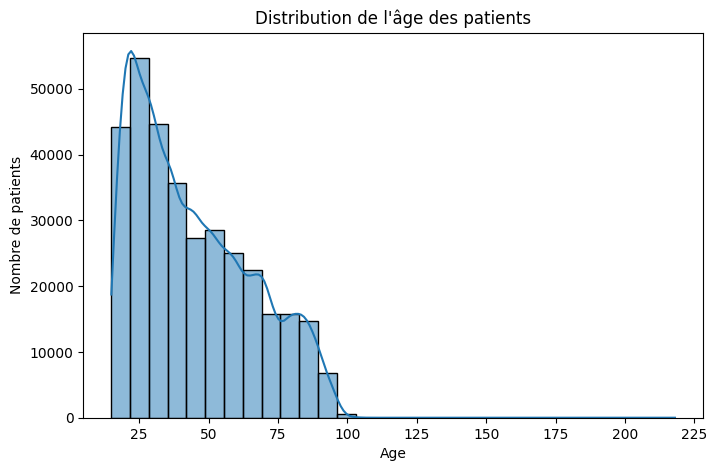

In [3]:
plt.figure(figsize=(8,5))
sns.histplot(df["_patient_age_en_anne"], bins=30, kde=True)
plt.title("Distribution de l'âge des patients")
plt.xlabel("Age")
plt.ylabel("Nombre de patients")
plt.show()

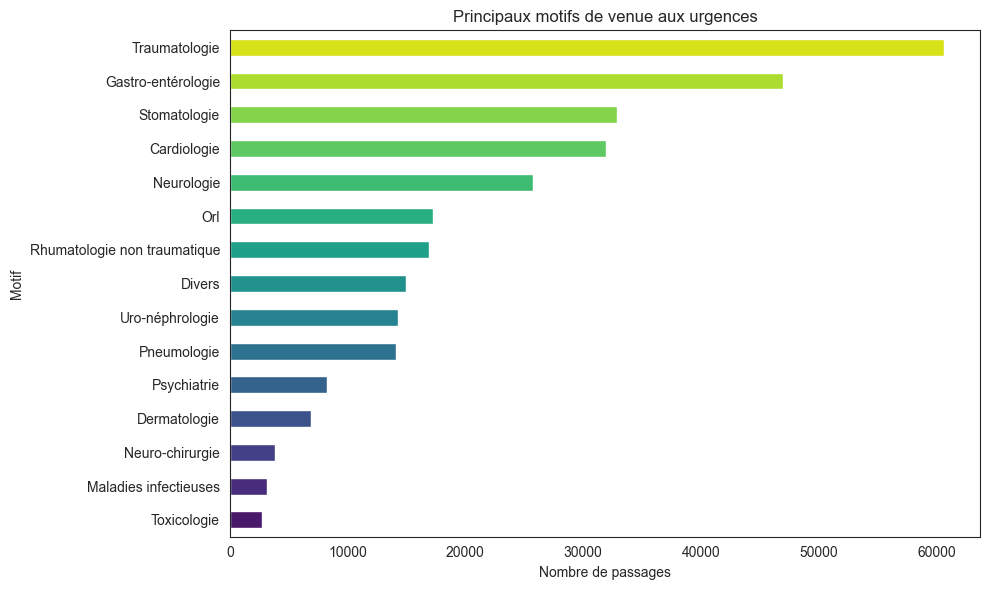

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("white")

motif_simple = (
    df["_iao_motif_de_venue"]
    .str.split(":").str[0]
    .str.strip()
)

motif_simple = motif_simple.replace("", None).dropna()

top_motifs = motif_simple.value_counts().head(15)

plt.figure(figsize=(10,6))

colors = sns.color_palette("viridis", len(top_motifs))

top_motifs.sort_values().plot(kind="barh", color=colors)

plt.title("Principaux motifs de venue aux urgences")
plt.xlabel("Nombre de passages")
plt.ylabel("Motif")

plt.grid(False)
plt.tight_layout()
plt.show()

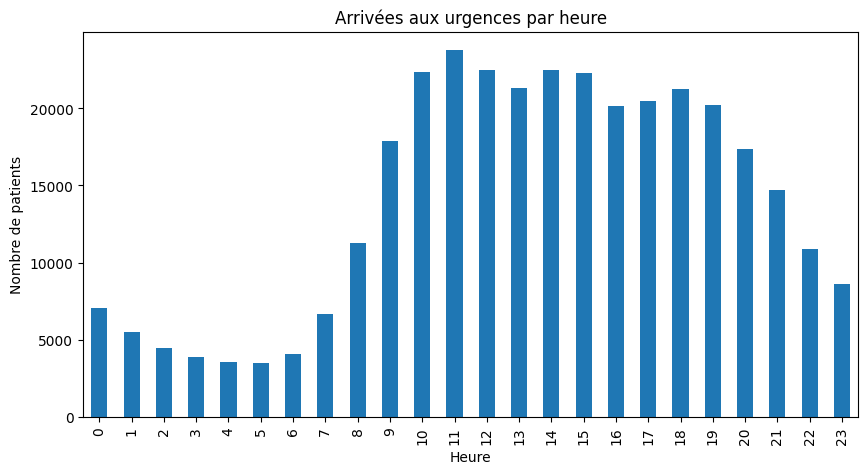

In [18]:
df["heure_dt"] = pd.to_datetime(df["heure"], format="%H:%M:%S", errors="coerce")
df["heure_dt"] = df["heure_dt"].dt.hour


arrivees = df["heure_dt"].value_counts().sort_index()

plt.figure(figsize=(10,5))
arrivees.plot(kind="bar")

plt.title("Arrivées aux urgences par heure")
plt.xlabel("Heure")
plt.ylabel("Nombre de patients")
plt.show()


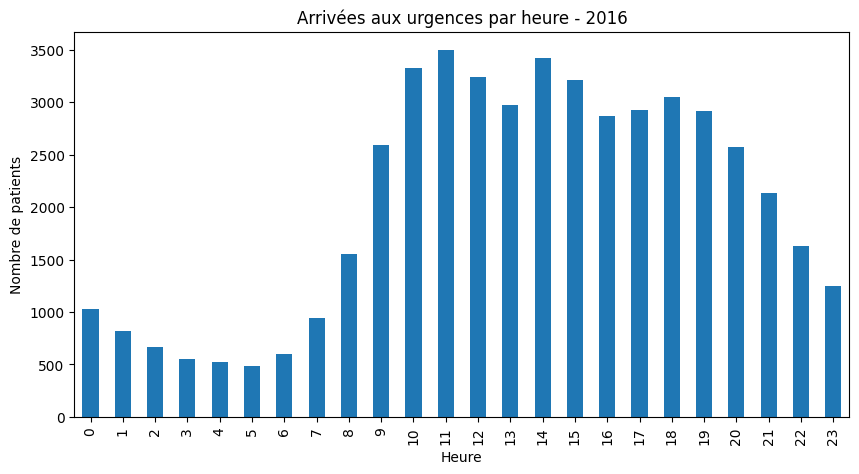

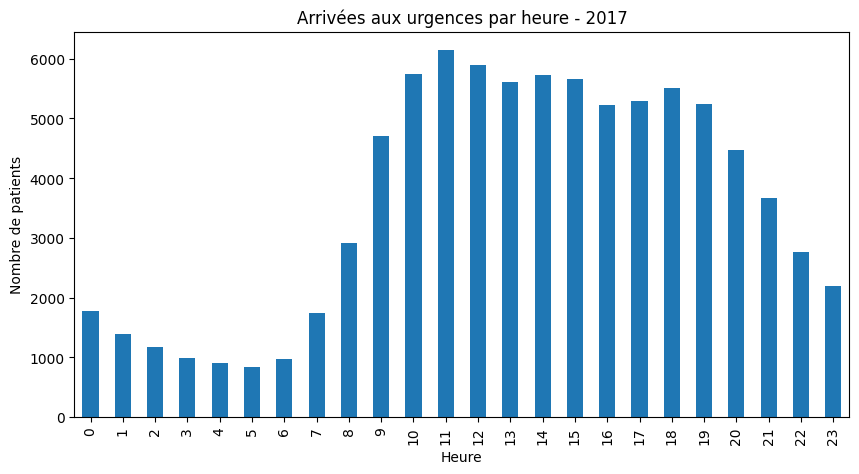

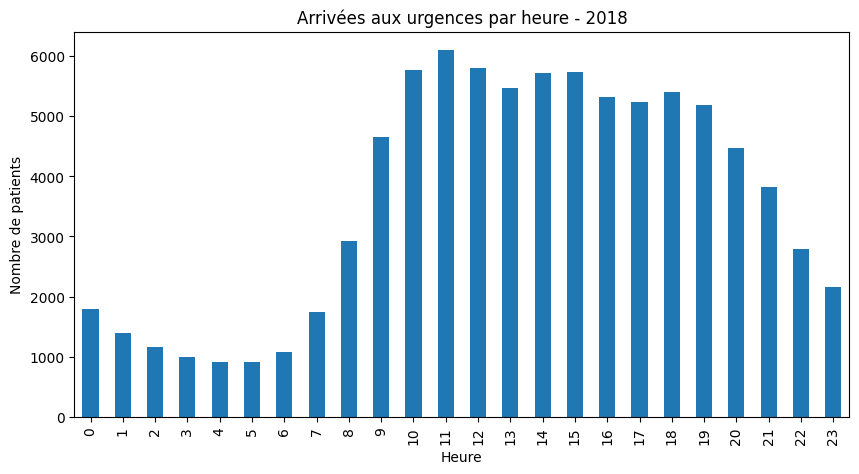

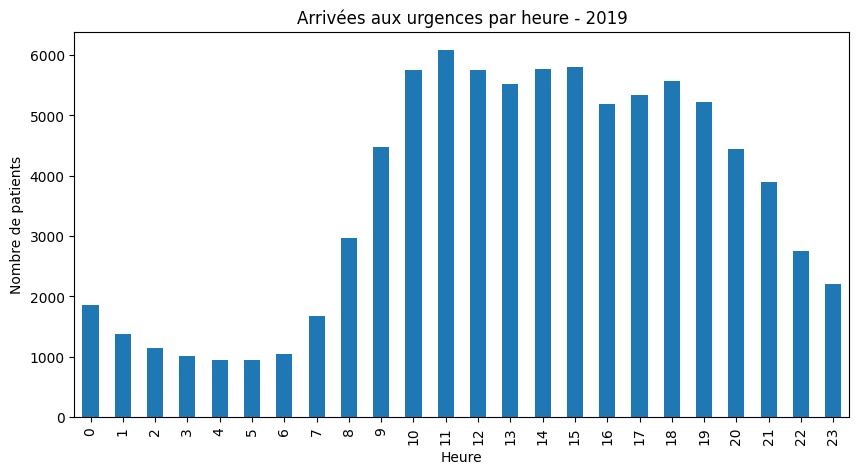

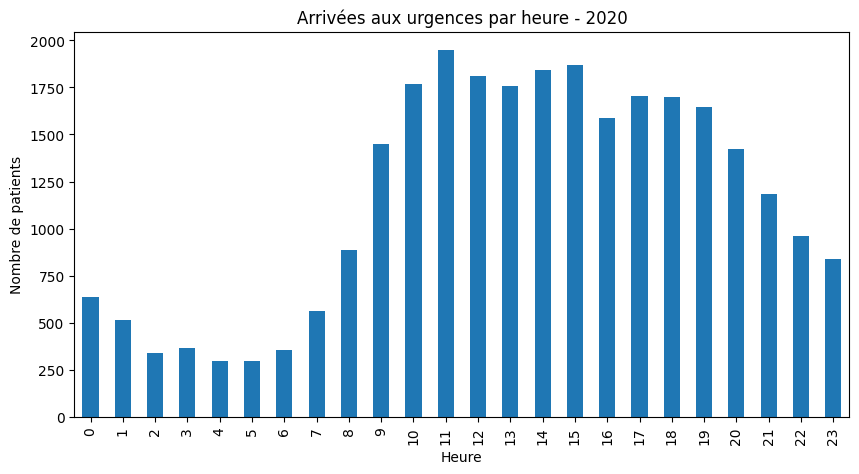

In [22]:
df["date_dt"] = pd.to_datetime(df["date"], errors="coerce")
df["annee"] = df["date_dt"].dt.year

import matplotlib.pyplot as plt

annees = sorted(df["annee"].dropna().unique())

for an in annees:
    
    data = df[df["annee"] == an]["heure_dt"].value_counts().sort_index()

    plt.figure(figsize=(10,5))
    data.plot(kind="bar")

    plt.title(f"Arrivées aux urgences par heure - {an}")
    plt.xlabel("Heure")
    plt.ylabel("Nombre de patients")
    plt.show()

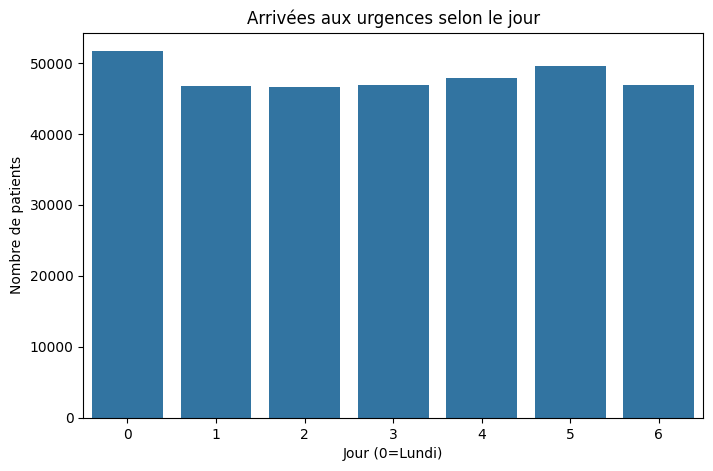

In [20]:
df["jour"] = pd.to_datetime(df["date"]).dt.dayofweek

plt.figure(figsize=(8,5))

sns.countplot(x="jour", data=df)

plt.title("Arrivées aux urgences selon le jour")
plt.xlabel("Jour (0=Lundi)")
plt.ylabel("Nombre de patients")
plt.show()

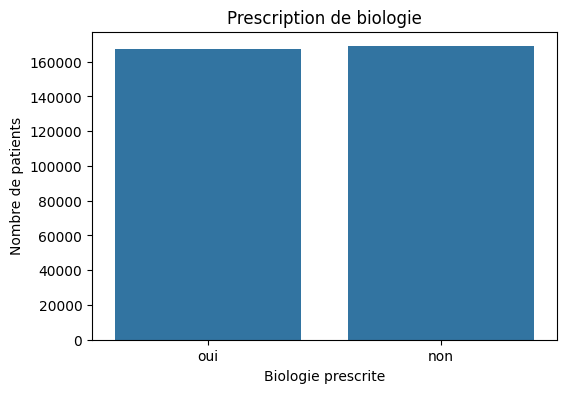

In [9]:
plt.figure(figsize=(6,4))

sns.countplot(x="_examens_complmentaires_a_des_examens_de_biologie", data=df)

plt.title("Prescription de biologie")
plt.xlabel("Biologie prescrite")
plt.ylabel("Nombre de patients")
plt.show()

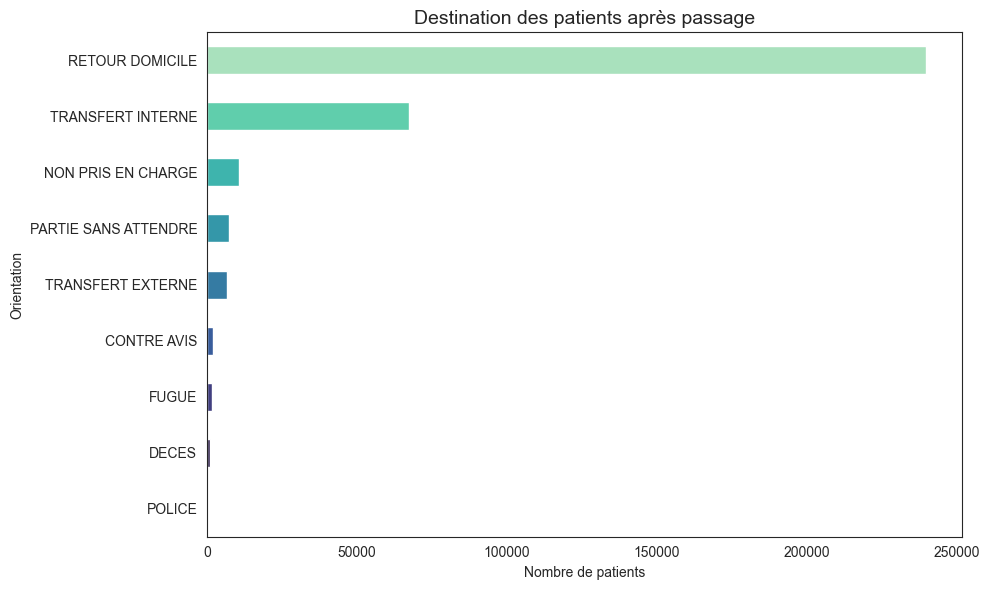

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("white")

orientation = df["_orientation_type_dorientation"].dropna()

top_orientation = orientation.value_counts().head(10)

plt.figure(figsize=(10,6))

colors = sns.color_palette("mako", len(top_orientation))

top_orientation.sort_values().plot(
    kind="barh",
    color=colors
)

plt.title("Destination des patients après passage", fontsize=14)
plt.xlabel("Nombre de patients")
plt.ylabel("Orientation")

plt.grid(False)
plt.tight_layout()

plt.show()

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Datetimes (adapte si tes colonnes ont déjà été converties)
df["arrive_dt"] = pd.to_datetime(df["_informations_du_passage_date_et_heure_darrive"], errors="coerce")
df["sortie_dt"] = pd.to_datetime(df["_informations_du_passage_date_et_heure_de_sortie"], errors="coerce")
df["box_dt"]    = pd.to_datetime(df["_localisation_date_dentre_en_box"], errors="coerce")
df["pec_dt"]    = pd.to_datetime(df["_informations_du_passage_date_dbut_prise_en_charge_mdicale"], errors="coerce")

# Durées (en minutes)
df["temps_total_urgences_min"] = (df["sortie_dt"] - df["arrive_dt"]).dt.total_seconds() / 60
df["attente_box_min"]          = (df["box_dt"]    - df["arrive_dt"]).dt.total_seconds() / 60
df["attente_pec_min"]          = (df["pec_dt"]    - df["arrive_dt"]).dt.total_seconds() / 60

# Nettoyage : garder seulement les valeurs plausibles (ex: 0 à 48h)
def clean_minutes(s, max_min=48*60):
    s = s.replace([np.inf, -np.inf], np.nan)
    s = s.where((s >= 0) & (s <= max_min))
    return s.dropna()

t_total = clean_minutes(df["temps_total_urgences_min"])
t_box   = clean_minutes(df["attente_box_min"])
t_pec   = clean_minutes(df["attente_pec_min"])

In [37]:
df.dtypes


num_dordre                                                                            int64
date                                                                         datetime64[ns]
heure                                                                                object
_informations_du_passage_date_et_heure_darrive                               datetime64[ns]
_informations_du_passage_moyen_darrive                                               object
_iao_motif_dentre                                                                    object
_iao_motif_de_venue                                                                  object
_patient_age_en_anne                                                                  int64
_antcdent_antcdents_mdicaux                                                          object
_antcdent_antcdents_chirurgicaux                                                     object
_constante_surveillances_paspad_adultes_premire_valeur                          

In [38]:
import pandas as pd
import numpy as np

# ----------------------------
# 1) Base: date du jour + arrivée (date + heure)
# ----------------------------
df["date_dt"] = pd.to_datetime(df["date"], dayfirst=True, errors="coerce").dt.normalize()
df["heure_td"] = pd.to_timedelta(df["heure"].astype(str), errors="coerce")
df["arrive_dt"] = df["date_dt"] + df["heure_td"]

# ----------------------------
# 2) Helper: convertir une colonne Excel serial (ex: "42522,04583") -> datetime
# ----------------------------
def excel_serial_to_dt(s):
    num = pd.to_numeric(s.astype(str).str.replace(",", ".", regex=False), errors="coerce")
    return pd.to_datetime(num, unit="D", origin="1899-12-30", errors="coerce")

# Colonnes Excel serial dans ton fichier (d'après ton exemple)
excel_cols = {
    "_localisation_date_dentre_en_box": "box_dt",
    "_informations_du_passage_date_dbut_prise_en_charge_mdicale": "pec_dt",
    "_informations_du_passage_date_et_heure_de_sortie": "sortie_dt",
    "_examens_complmentaires_date_et_heure_de_premire_prescription_de_biologie": "bio_presc_dt",
    "_examens_complmentaires_date_et_heure_de_premier_prlvement_de_biologie": "bio_prel_dt",
}

for col_src, col_out in excel_cols.items():
    if col_src in df.columns:
        df[col_out] = excel_serial_to_dt(df[col_src])
    else:
        df[col_out] = pd.NaT

# ----------------------------
# 3) Cohérence minuit: si événement < arrivée -> + 1 jour
# ----------------------------
for col in ["box_dt", "pec_dt", "bio_presc_dt", "bio_prel_dt", "sortie_dt"]:
    mask = df[col].notna() & df["arrive_dt"].notna() & (df[col] < df["arrive_dt"])
    df.loc[mask, col] = df.loc[mask, col] + pd.Timedelta(days=1)

# ----------------------------
# 4) Durées (minutes)
# ----------------------------
df["temps_total_urgences_min"] = (df["sortie_dt"] - df["arrive_dt"]).dt.total_seconds() / 60
df["attente_box_min"]          = (df["box_dt"]    - df["arrive_dt"]).dt.total_seconds() / 60
df["attente_pec_min"]          = (df["pec_dt"]    - df["arrive_dt"]).dt.total_seconds() / 60

df["delai_presc_bio_min"]      = (df["bio_presc_dt"] - df["arrive_dt"]).dt.total_seconds() / 60
df["delai_prel_bio_min"]       = (df["bio_prel_dt"]  - df["arrive_dt"]).dt.total_seconds() / 60

# ----------------------------
# 5) Vérifs conversion + plausibilité
# ----------------------------
def report_dt(src_col, dt_col):
    nonnull = df[src_col].notna().sum() if src_col in df.columns else 0
    ok = df[dt_col].notna().sum()
    rate = ok/nonnull if nonnull else np.nan
    print(f"{dt_col} <- {src_col} | non-null src={nonnull} | dt ok={ok} | taux={rate:.3f}" if nonnull else f"{dt_col}: source absente")

for src, out in excel_cols.items():
    if src in df.columns:
        report_dt(src, out)

print("\narrive_dt ok:", df["arrive_dt"].notna().sum(), "/", len(df))

def report_duration(col, max_min):
    s = pd.to_numeric(df[col], errors="coerce")
    ok = s.notna().sum()
    neg = (s < 0).sum()
    big = (s > max_min).sum()
    print(f"{col}: ok={ok} | négatifs={neg} | >{max_min}min={big}")
    if ok:
        print(s.describe(percentiles=[.5,.75,.9,.95,.99]))
        print("----")

report_duration("temps_total_urgences_min", max_min=72*60)
report_duration("attente_box_min",          max_min=24*60)
report_duration("attente_pec_min",          max_min=24*60)

# Aperçu pour valider visuellement sur tes 1ères lignes
df[[
    "date","heure","arrive_dt",
    "pec_dt","box_dt","sortie_dt",
    "temps_total_urgences_min","attente_pec_min","attente_box_min"
]].head(5)

box_dt <- _localisation_date_dentre_en_box | non-null src=186938 | dt ok=186938 | taux=1.000
pec_dt <- _informations_du_passage_date_dbut_prise_en_charge_mdicale | non-null src=298023 | dt ok=298023 | taux=1.000
sortie_dt <- _informations_du_passage_date_et_heure_de_sortie | non-null src=336253 | dt ok=336253 | taux=1.000
bio_presc_dt <- _examens_complmentaires_date_et_heure_de_premire_prescription_de_biologie | non-null src=167448 | dt ok=167448 | taux=1.000
bio_prel_dt <- _examens_complmentaires_date_et_heure_de_premier_prlvement_de_biologie | non-null src=164481 | dt ok=164481 | taux=1.000

arrive_dt ok: 336253 / 336253
temps_total_urgences_min: ok=336253 | négatifs=0 | >4320min=3353
count    336253.000000
mean        488.344196
std        1331.237416
min           0.000000
50%         271.000000
75%         471.000000
90%         937.000000
95%        1554.000000
99%        4315.480000
max      313899.000000
Name: temps_total_urgences_min, dtype: float64
----
attente_box_min: ok=18

,date,heure,arrive_dt,pec_dt,box_dt,sortie_dt,temps_total_urgences_min,attente_pec_min,attente_box_min
0,2016-06-01,00:16:00,2016-06-01 00:16:00,2016-06-01 01:02:59.999999749,2016-06-01 01:05:59.999997189,2016-06-01 04:14:00.000001271,238.0,47.0,50.0
1,2016-06-01,00:18:00,2016-06-01 00:18:00,2016-06-01 02:13:59.999995407,2016-06-01 01:32:00.000001020,2016-06-01 11:05:00.000003701,647.0,116.0,74.0
2,2016-06-01,00:36:00,2016-06-01 00:36:00,NaT,2016-06-01 00:40:59.999997959,2016-06-01 03:04:00.000002040,148.0,NaN,5.0
3,2016-06-01,00:43:00,2016-06-01 00:43:00,2016-06-01 01:57:00.000000250,2016-06-01 01:36:00.000003061,2016-06-01 04:50:00.000000769,247.0,74.0,53.0
4,2016-06-01,01:16:00,2016-06-01 01:16:00,2016-06-01 02:35:00.000000769,2016-06-01 01:36:00.000003061,2016-06-01 15:54:59.999996298,879.0,79.0,20.0


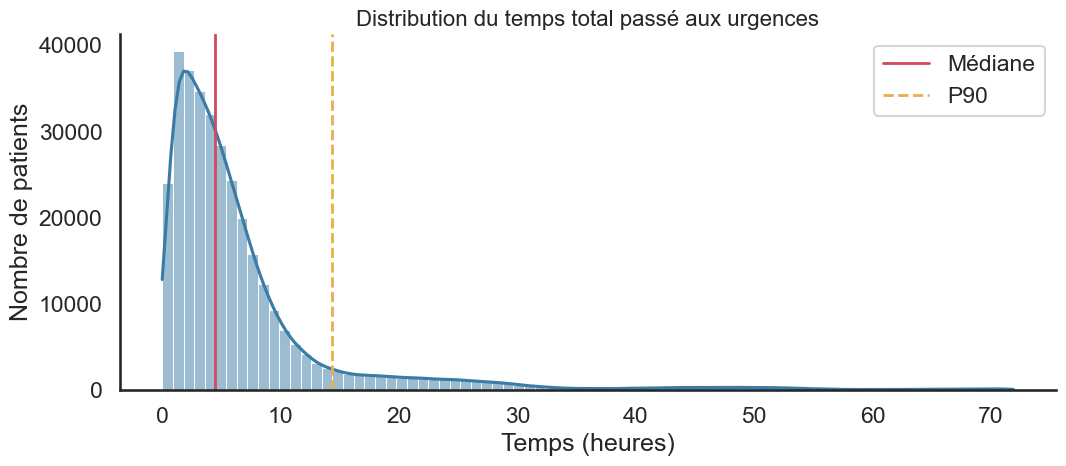

In [50]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white", context="talk")

temps = df["temps_total_urgences_min"] / 60

# enlever les 1% les plus extrêmes
seuil = np.percentile(temps.dropna(), 99)
temps_filtre = temps[temps <= seuil]

plt.figure(figsize=(11,5))

sns.histplot(
    temps_filtre,
    bins=80,
    kde=True,
    color="#3A7CA5"
)

# médiane et percentile 90
plt.axvline(np.percentile(temps_filtre,50), color="#D1495B", linewidth=2, label="Médiane")
plt.axvline(np.percentile(temps_filtre,90), color="#EDAe49", linewidth=2, linestyle="--", label="P90")

plt.title("Distribution du temps total passé aux urgences", fontsize=16)
plt.xlabel("Temps (heures)")
plt.ylabel("Nombre de patients")

plt.legend()
sns.despine()

plt.tight_layout()
plt.show()

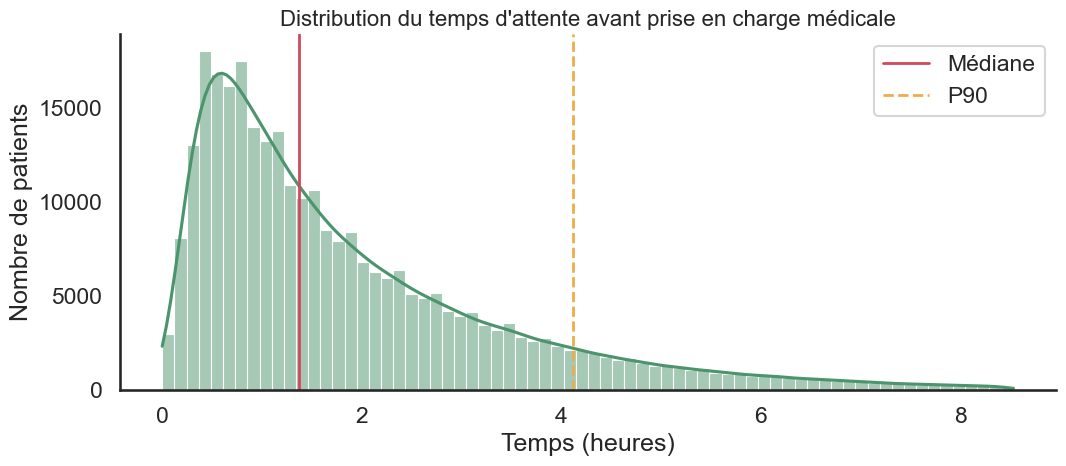

In [51]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white", context="talk")

attente = df["attente_pec_min"] / 60

seuil = np.percentile(attente.dropna(), 99)
attente_filtre = attente[attente <= seuil]

plt.figure(figsize=(11,5))

sns.histplot(
    attente_filtre,
    bins=70,
    kde=True,
    color="#4C956C"
)

plt.axvline(np.percentile(attente_filtre,50), color="#D1495B", linewidth=2, label="Médiane")
plt.axvline(np.percentile(attente_filtre,90), color="#EDAe49", linewidth=2, linestyle="--", label="P90")

plt.title("Distribution du temps d'attente avant prise en charge médicale", fontsize=16)
plt.xlabel("Temps (heures)")
plt.ylabel("Nombre de patients")

plt.legend()
sns.despine()

plt.tight_layout()
plt.show()

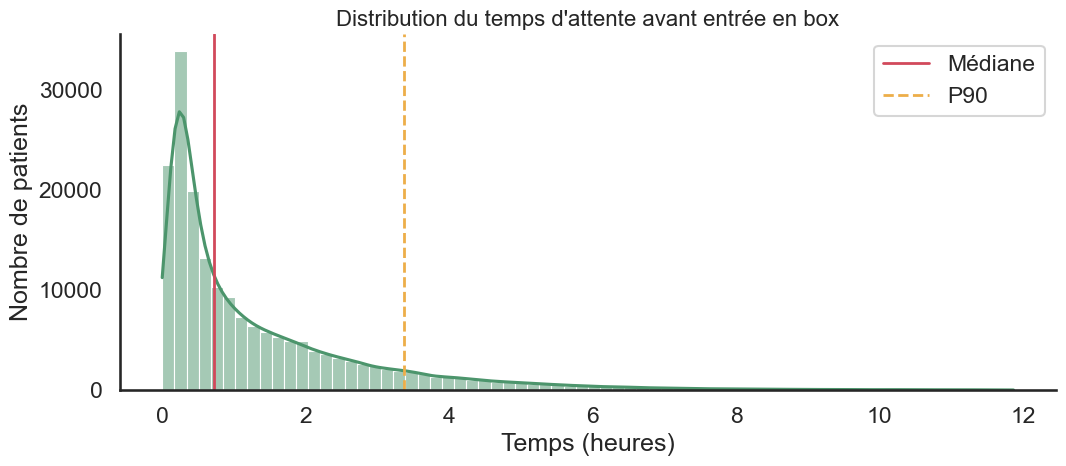

In [53]:
sns.set_theme(style="white", context="talk")

attente_box = df["attente_box_min"] / 60

seuil = np.percentile(attente_box.dropna(), 99)
attente_box_filtre = attente_box[attente_box <= seuil]

plt.figure(figsize=(11,5))

sns.histplot(
    attente_box_filtre,
    bins=70,
    kde=True,
    color="#4C956C"
)

plt.axvline(np.percentile(attente_box_filtre,50), color="#D1495B", linewidth=2, label="Médiane")
plt.axvline(np.percentile(attente_box_filtre,90), color="#EDAe49", linewidth=2, linestyle="--", label="P90")

plt.title("Distribution du temps d'attente avant entrée en box", fontsize=16)
plt.xlabel("Temps (heures)")
plt.ylabel("Nombre de patients")

plt.legend()
sns.despine()

plt.tight_layout()
plt.show()

# Prédiction de la charge du personnel médical par jour/par mois/par an

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("white")

# --- paramètres
SHIFT_H = 8 # duree du shift en heures
TAUX_PRODUCTIF = 0.70
CAPACITE_PAR_PERSONNE_H = SHIFT_H * TAUX_PRODUCTIF   # ex 5.6h utiles/jour/personne

ccmu_weights = {1:1.0, 2:1.3, 3:1.8, 4:2.5, 5:3.0}   # pondération "effort" (plus réaliste que 1,2,4,8)

In [79]:
# CCMU
df["ccmu_num"] = pd.to_numeric(df["_diagnostic_code_ccmu"], errors="coerce")
df["ccmu_w"] = df["ccmu_num"].map(ccmu_weights).fillna(1.0)

# charge en heures (proxy)
df["charge_h"] = (df["temps_total_urgences_min"] / 60)

# charge pondérée
df["charge_ponderee_h"] = df["charge_h"] * df["ccmu_w"]

# jour d'arrivée
df["jour"] = df["arrive_dt"].dt.floor("D")

In [80]:
# examens (booléens oui/non)
exam_cols = [
    "_examens_complmentaires_a_des_examens_de_biologie",
    "_examens_complmentaires_a_des_examens_de_radiologie",
    "_examens_complmentaires_a_des_examens_dchographie",
    "_examens_complmentaires_a_des_examens_de_scanner",
    "_examens_complmentaires_a_des_examens_dirm",
    "_examens_complmentaires_a_des_avis_de_spcialistes",
]
for c in exam_cols:
    if c in df.columns:
        df[c] = df[c].astype(str).str.lower().isin(["oui", "true", "1", "yes"])

# âge
df["age"] = pd.to_numeric(df["_patient_age_en_anne"], errors="coerce")

# agrégation par jour
daily = pd.DataFrame(index=df["jour"].dropna().sort_values().unique())
daily.index.name = "jour"

# cible y : personnel requis (équivalent)
daily["charge_ponderee_h"] = df.groupby("jour")["charge_ponderee_h"].sum()
daily["personnel_requis"] = daily["charge_ponderee_h"] / CAPACITE_PAR_PERSONNE_H

# volume
daily["patients"] = df.groupby("jour").size()

# CCMU stats
daily["ccmu_mean"] = df.groupby("jour")["ccmu_num"].mean()

# proportions CCMU 1..5
for k in [1,2,3,4,5]:
    daily[f"ccmu_prop_{k}"] = (df["ccmu_num"].eq(k)).groupby(df["jour"]).mean()

# examens (taux)
for c in exam_cols:
    if c in df.columns:
        daily[c.replace("_examens_complmentaires_a_des_", "taux_")] = df.groupby("jour")[c].mean()

# âge moyen
daily["age_mean"] = df.groupby("jour")["age"].mean()

# variables calendrier
daily["dow"] = pd.to_datetime(daily.index).dayofweek     # 0=lundi
daily["month"] = pd.to_datetime(daily.index).month
daily["year"] = pd.to_datetime(daily.index).year

daily = daily.dropna(subset=["personnel_requis", "patients"])
daily.head()

,charge_ponderee_h,personnel_requis,patients,ccmu_mean,ccmu_prop_1,ccmu_prop_2,ccmu_prop_3,ccmu_prop_4,ccmu_prop_5,taux_examens_de_biologie,taux_examens_de_radiologie,taux_examens_dchographie,taux_examens_de_scanner,taux_examens_dirm,taux_avis_de_spcialistes,age_mean,dow,month,year
jour,,,,,,,,,,,,,,,,,,,
2016-06-01,1860.008333,332.144345,220,2.033981,0.104545,0.745455,0.059091,0.004545,0.022727,0.550000,0.304545,0.063636,0.127273,0.068182,0.450000,44.254545,2,6,2016
2016-06-02,2084.295000,372.195536,209,2.035897,0.138756,0.669856,0.095694,0.009569,0.019139,0.483254,0.330144,0.028708,0.119617,0.052632,0.425837,44.177033,3,6,2016
2016-06-03,2997.146667,535.204762,227,1.980676,0.171806,0.625551,0.088106,0.013216,0.013216,0.493392,0.277533,0.039648,0.140969,0.026432,0.392070,45.982379,4,6,2016
2016-06-04,1895.625000,338.504464,237,2.130045,0.063291,0.742616,0.101266,0.016878,0.016878,0.417722,0.329114,0.029536,0.092827,0.037975,0.485232,44.345992,5,6,2016
2016-06-05,2446.030000,436.791071,227,2.056872,0.048458,0.814978,0.044053,0.008811,0.013216,0.365639,0.321586,0.035242,0.123348,0.026432,0.519824,41.533040,6,6,2016


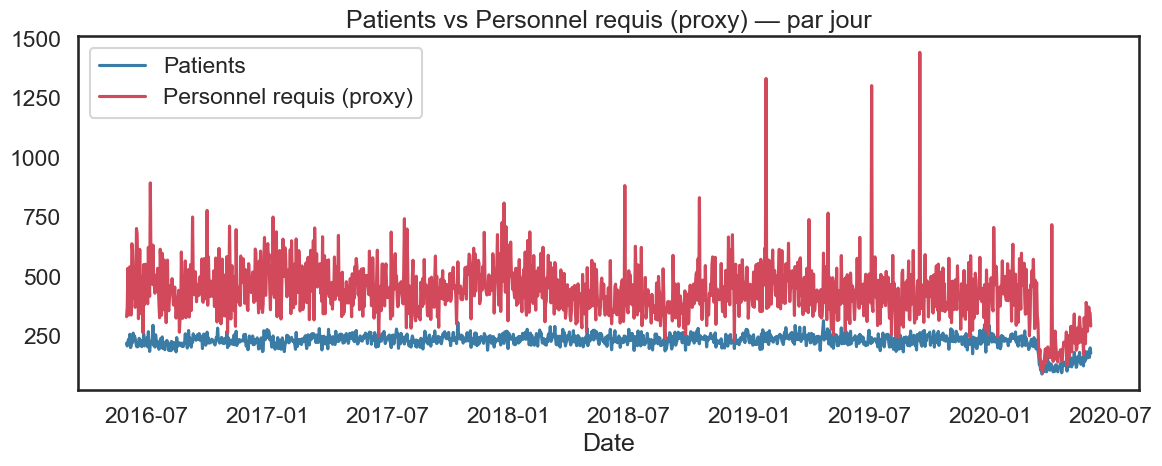

In [81]:
plt.figure(figsize=(12,5))
plt.plot(daily.index, daily["patients"], label="Patients", color="#3A7CA5")
plt.plot(daily.index, daily["personnel_requis"], label="Personnel requis (proxy)", color="#D1495B")
plt.title("Patients vs Personnel requis (proxy) — par jour")
plt.xlabel("Date")
plt.grid(False)
plt.legend()
plt.tight_layout()
plt.show()

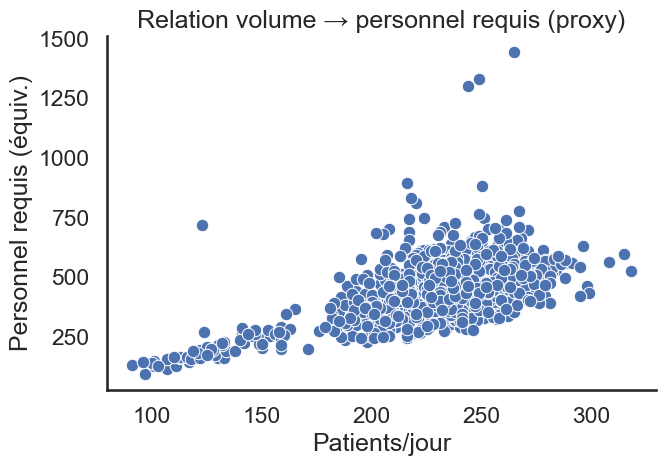

In [82]:
plt.figure(figsize=(7,5))
sns.scatterplot(x=daily["patients"], y=daily["personnel_requis"])
plt.title("Relation volume → personnel requis (proxy)")
plt.xlabel("Patients/jour")
plt.ylabel("Personnel requis (équiv.)")
sns.despine()
plt.tight_layout()
plt.show()

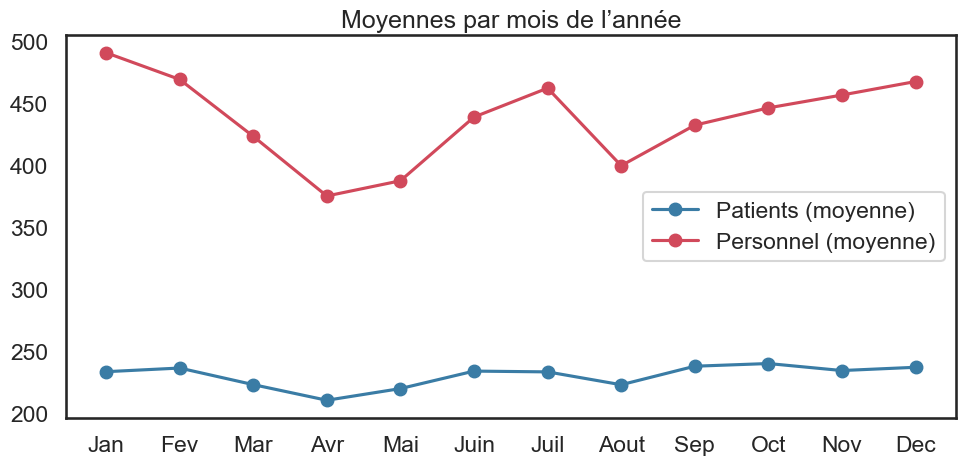

In [83]:
mois = daily.groupby("month")[["patients","personnel_requis"]].mean()

plt.figure(figsize=(10,5))
plt.plot(mois.index, mois["patients"], marker="o", color="#3A7CA5", label="Patients (moyenne)")
plt.plot(mois.index, mois["personnel_requis"], marker="o", color="#D1495B", label="Personnel (moyenne)")
plt.xticks(range(1,13), ["Jan","Fev","Mar","Avr","Mai","Juin","Juil","Aout","Sep","Oct","Nov","Dec"])
plt.title("Moyennes par mois de l’année")
plt.grid(False)
plt.legend()
plt.tight_layout()
plt.show()

In [84]:
temps_med_ccmu = {
1:10,
2:20,
3:35,
4:60,
5:90
}

df["temps_med_min"] = df["ccmu_num"].map(temps_med_ccmu).fillna(20)

df["charge_medicale_h"] = df["temps_med_min"] / 60

In [85]:
CAPACITE_PAR_PERSONNE_H = 6   # ~6h utiles par médecin / jour

df["jour"] = df["arrive_dt"].dt.floor("D")

charge_jour = df.groupby("jour")["charge_medicale_h"].sum()

personnel_requis = charge_jour / CAPACITE_PAR_PERSONNE_H

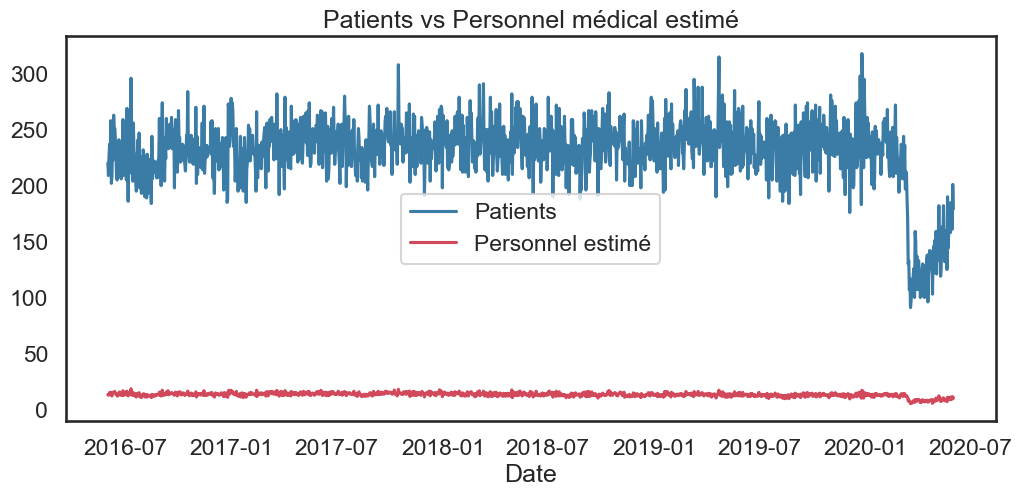

In [86]:
patients_jour = df.groupby("jour").size()

plt.figure(figsize=(12,5))

plt.plot(patients_jour.index, patients_jour, label="Patients", color="#3A7CA5")
plt.plot(personnel_requis.index, personnel_requis, label="Personnel estimé", color="#D1495B")

plt.title("Patients vs Personnel médical estimé")
plt.xlabel("Date")

plt.legend()
plt.grid(False)

plt.show()

# ML

In [87]:
features = pd.DataFrame()

features["patients"] = df.groupby("jour").size()

features["ccmu_moyen"] = df.groupby("jour")["ccmu_num"].mean()

features["age_moyen"] = df.groupby("jour")["age"].mean()

features["jour_semaine"] = pd.to_datetime(features.index).dayofweek
features["mois"] = pd.to_datetime(features.index).month

# cible
target = personnel_requis

In [88]:
data = features.copy()
data["personnel"] = target

data = data.dropna()

In [89]:
train = data.iloc[:-365]
test = data.iloc[-365:]

X_train = train.drop(columns="personnel")
y_train = train["personnel"]

X_test = test.drop(columns="personnel")
y_test = test["personnel"]

In [90]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)

pred = model.predict(X_test)

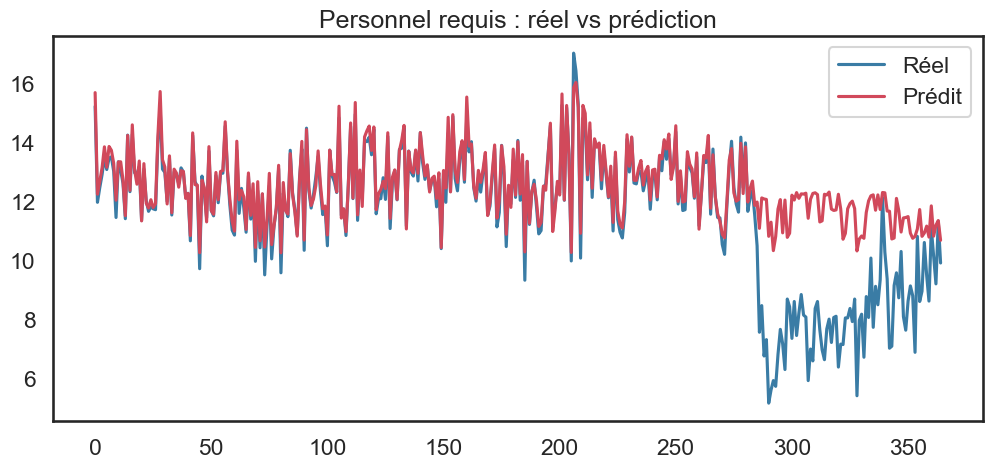

In [91]:
plt.figure(figsize=(12,5))

plt.plot(y_test.values, label="Réel", color="#3A7CA5")
plt.plot(pred, label="Prédit", color="#D1495B")

plt.title("Personnel requis : réel vs prédiction")

plt.legend()

plt.grid(False)

plt.show()

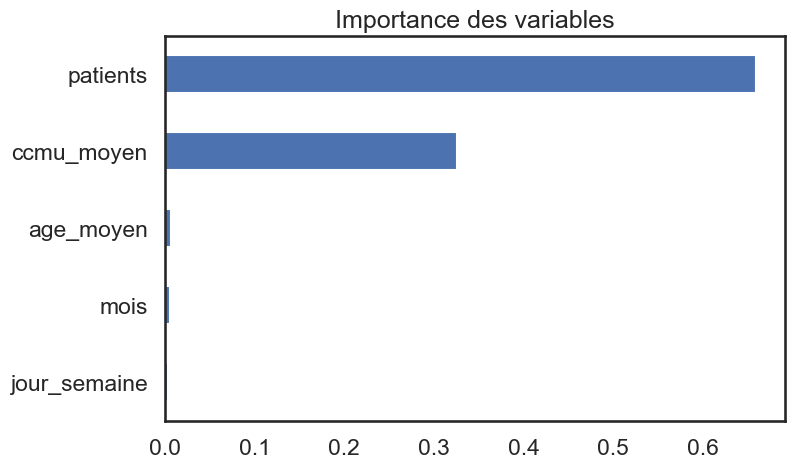

In [92]:
import pandas as pd

importance = pd.Series(
    model.feature_importances_,
    index=X_train.columns
).sort_values()

plt.figure(figsize=(8,5))

importance.plot(kind="barh")

plt.title("Importance des variables")

plt.grid(False)

plt.show()

# Résultats

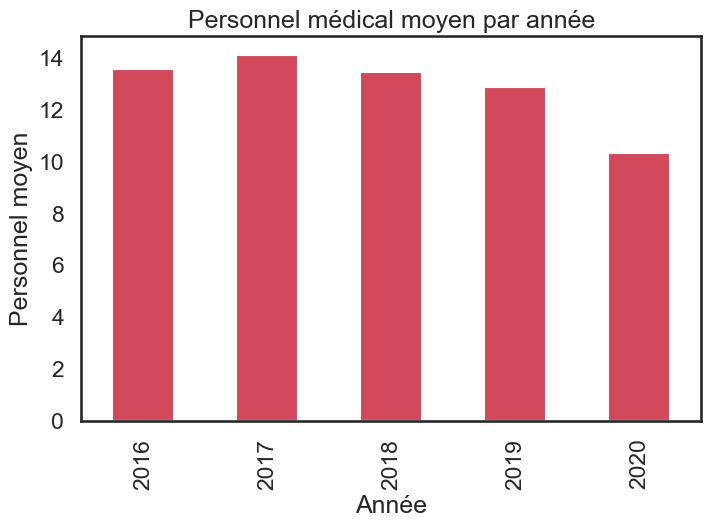

In [93]:
personnel_annee = personnel_requis.groupby(
    personnel_requis.index.year
).mean()

plt.figure(figsize=(8,5))

personnel_annee.plot(kind="bar", color="#D1495B")

plt.title("Personnel médical moyen par année")
plt.xlabel("Année")
plt.ylabel("Personnel moyen")

plt.grid(False)
plt.show()

/var/folders/1x/rzpvcrbd5jj7cgj4c0qm20k40000gn/T/ipykernel_52125/2532569858.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  personnel_mois = personnel_requis.resample("M").mean()


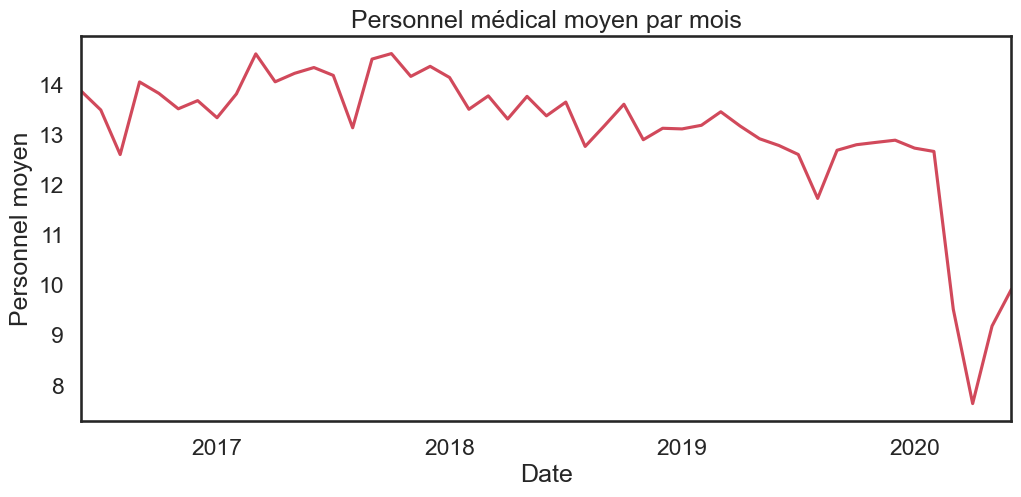

In [94]:
personnel_mois = personnel_requis.resample("M").mean()

plt.figure(figsize=(12,5))

personnel_mois.plot(color="#D1495B")

plt.title("Personnel médical moyen par mois")
plt.xlabel("Date")
plt.ylabel("Personnel moyen")

plt.grid(False)
plt.show()

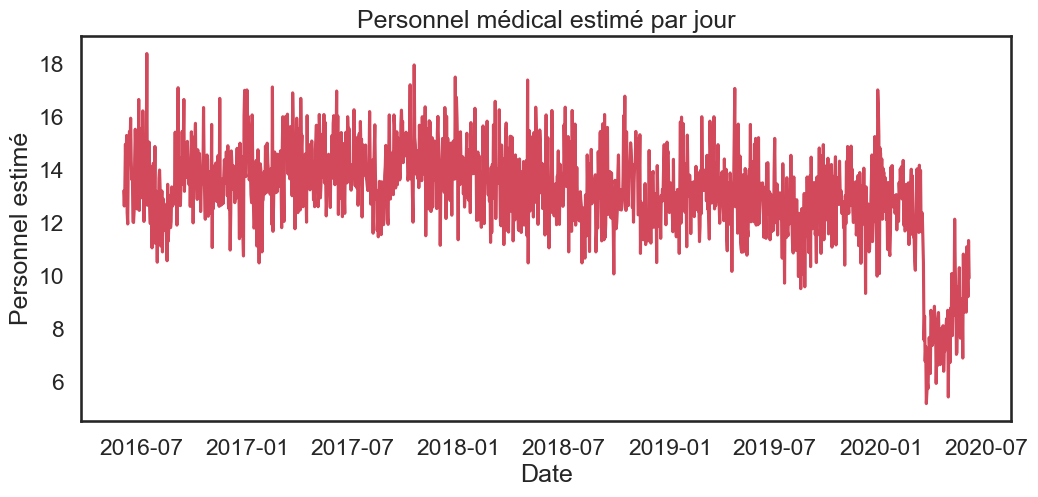

In [95]:
plt.figure(figsize=(12,5))

plt.plot(personnel_requis.index, personnel_requis, color="#D1495B")

plt.title("Personnel médical estimé par jour")
plt.xlabel("Date")
plt.ylabel("Personnel estimé")

plt.grid(False)
plt.show()

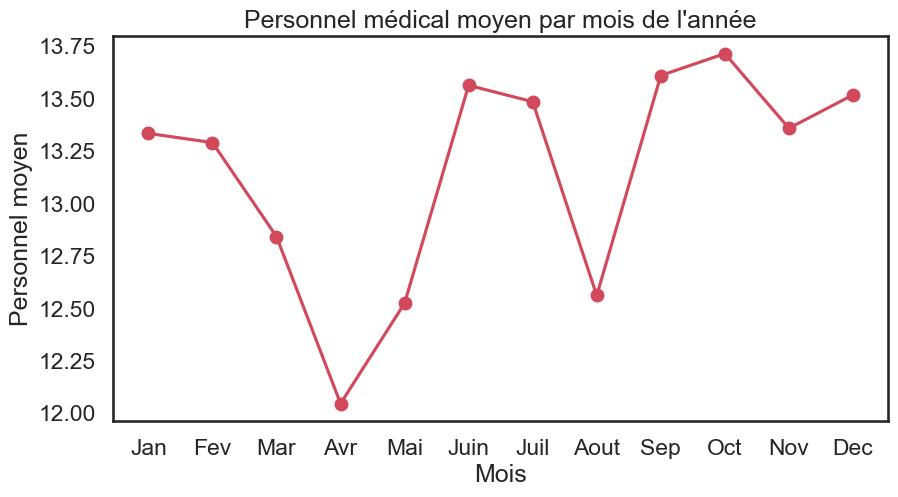

In [96]:
personnel_mois_annee = personnel_requis.groupby(
    personnel_requis.index.month
).mean()

mois_labels = [
"Jan","Fev","Mar","Avr","Mai","Juin",
"Juil","Aout","Sep","Oct","Nov","Dec"
]

plt.figure(figsize=(10,5))

plt.plot(personnel_mois_annee.index, personnel_mois_annee, marker="o", color="#D1495B")

plt.xticks(range(1,13), mois_labels)

plt.title("Personnel médical moyen par mois de l'année")
plt.xlabel("Mois")
plt.ylabel("Personnel moyen")

plt.grid(False)
plt.show()

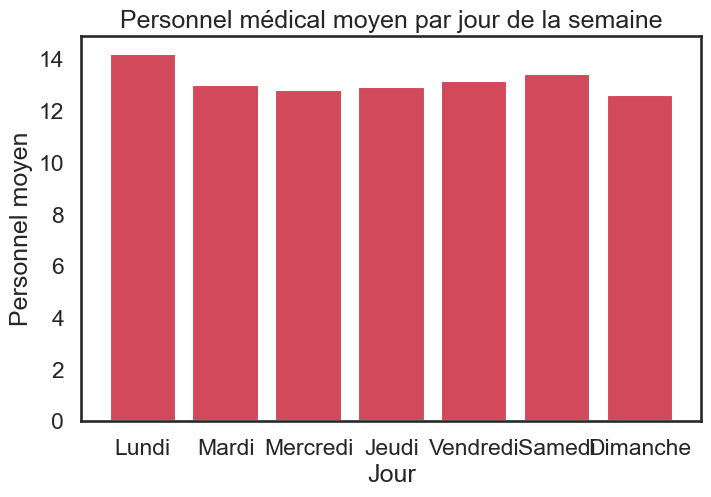

In [97]:
jours = [
"Lundi","Mardi","Mercredi",
"Jeudi","Vendredi","Samedi","Dimanche"
]

personnel_jour_semaine = personnel_requis.groupby(
    personnel_requis.index.dayofweek
).mean()

plt.figure(figsize=(8,5))

plt.bar(personnel_jour_semaine.index, personnel_jour_semaine, color="#D1495B")

plt.xticks(range(7), jours)

plt.title("Personnel médical moyen par jour de la semaine")
plt.xlabel("Jour")
plt.ylabel("Personnel moyen")

plt.grid(False)
plt.show()

In [98]:
df["heure"] = df["arrive_dt"].dt.hour
df["jour_semaine"] = df["arrive_dt"].dt.dayofweek

In [99]:
charge_horaire = df.groupby(["jour_semaine","heure"])["charge_medicale_h"].sum()

personnel_horaire = charge_horaire / CAPACITE_PAR_PERSONNE_H

In [100]:
heatmap_data = personnel_horaire.unstack(level=0)

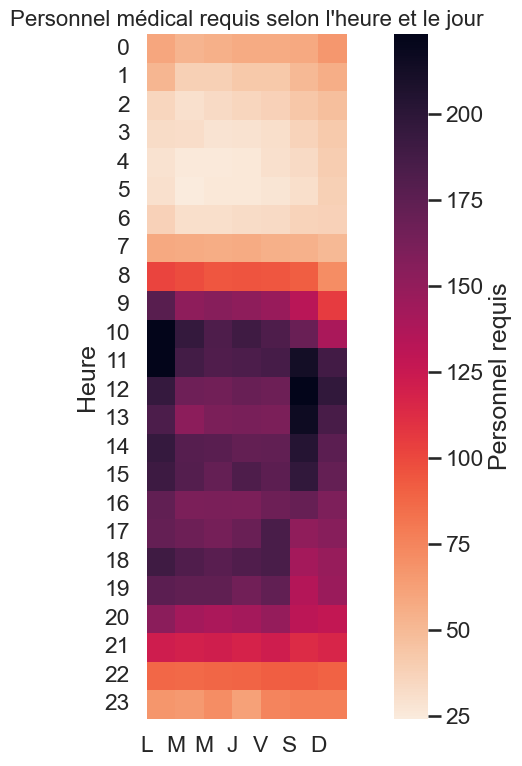

In [104]:
jours = ["L","M","M","J","V","S","D"]

plt.figure(figsize=(10,8))

sns.heatmap(
    heatmap_data,
    cmap="rocket_r",
    square=True,
    linewidths=0,
    cbar_kws={"label":"Personnel requis"}
)

plt.title(
"Personnel médical requis selon l'heure et le jour",
fontsize=16
)

plt.xlabel("")
plt.ylabel("Heure")

plt.xticks(range(7), jours, rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()

plt.show()